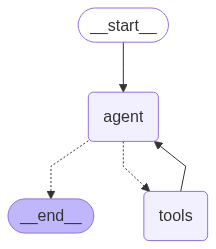

In [22]:
from dotenv import load_dotenv

load_dotenv()

# Import relevant functionality
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

# Create the agent
memory = MemorySaver()
model = init_chat_model("gpt-4o-mini", model_provider="openai")
search = TavilySearch(max_results=2)
tools = [search]
agent_executor = create_react_agent(model,tools, checkpointer=memory)
agent_executor

In [23]:
# Use the agent
config = {"configurable": {"thread_id": "abc123"}}

input_message = {
    "role": "user",
    "content": "Hi, I'm Bob and I live in SF.",
}
for step in agent_executor.stream(
    {"messages": [input_message]},
    config,
    stream_mode="values"
    # stream_mode="events"
    ):
    
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, I'm Bob and I live in SF.
================================== Ai Message ==================================

Hi Bob! How can I assist you today?


#### interrupt_after 구현

In [ ]:
# 1. 에이전트 구성
# 모델, 도구, 메모리(Checkpointer)를 준비합니다.
from langchain_openai import ChatOpenAI


model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
search_tool = TavilySearch(max_results=2)
tools = [search_tool]
memory = MemorySaver()

# ReAct 에이전트를 생성합니다.
agent_executor = create_react_agent(model, tools, checkpointer=memory)

# 2. 대화 세션 설정
# 동일한 thread_id를 사용해야 대화의 맥락이 유지됩니다.
config = {"configurable": {"thread_id": "human-in-the-loop-thread-1"}}

# 3. 첫 번째 호출: 도구 사용 후 멈추도록 설정
# 사용자가 날씨를 물어봅니다. 에이전트는 검색 도구를 사용해야 합니다.
initial_input = {"messages": [{"role": "user", "content": "샌프란시스코의 현재 날씨는 어떤가요?"}]}
print("🤖 에이전트 실행 시작...")
# interrupt_after=["tools"] 로 도구 사용 후 멈추도록 설정
for step in agent_executor.stream(initial_input,
                                  config,
                                  interrupt_after=["tools"],
                                  stream_mode="values"):
    
    # 스트리밍되는 각 단계를 출력합니다.
    step["messages"][-1].pretty_print()

print("\n" + "="*40)
print("⏸️ --- 인간의 개입: 에이전트가 일시 중지되었습니다 --- ⏸️")
print("="*40 + "\n")

🤖 에이전트 실행 시작...
================================ Human Message =================================

샌프란시스코의 현재 날씨는 어떤가요?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_AgupnPFNONpIMipqXlW2eojm)
 Call ID: call_AgupnPFNONpIMipqXlW2eojm
  Args:
    query: current weather in San Francisco
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "current weather in San Francisco", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in San Francisco", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1756812066, 'localtime': '2025-09-02 04:21'}, 'current': {'last_updated_epoch': 1756811700, 'last_updated': '2025-09-02 04:15', 'temp_c'

In [33]:
# 4. 중간 상태 확인
# 현재까지의 대화 상태를 가져와서 도구 실행 결과를 확인합니다.
current_state = agent_executor.get_state(config)
tool_output = current_state.values["messages"][-1]

print("🔍 [확인] 도구 실행 결과:")
print(f"도구: {tool_output}")
print(f"결과: {tool_output.content[:200]}...") # 결과가 길 수 있으므로 일부만 출력

# 여기서 사용자는 결과를 검토하거나, 데이터베이스에 로그를 남기는 등의 작업을 할 수 있습니다.

print("\n" + "="*40)
print("▶️ --- 에이전트 실행을 재개합니다 --- ▶️")
print("="*40 + "\n")

# 5. 실행 재개 및 최종 답변 받기
# input을 None으로 하여 이전 상태에서 계속 실행하도록 합니다.
# config는 반드시 동일한 것을 사용해야 합니다.
for step in agent_executor.stream(None, config,stream_mode="values"):
    step["messages"][-1].pretty_print()

print("\n✅ 에이전트 실행 완료!")

🔍 [확인] 도구 실행 결과:
도구: content='{"query": "current weather in San Francisco", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in San Francisco", "url": "https://www.weatherapi.com/", "content": "{\'location\': {\'name\': \'San Francisco\', \'region\': \'California\', \'country\': \'United States of America\', \'lat\': 37.775, \'lon\': -122.4183, \'tz_id\': \'America/Los_Angeles\', \'localtime_epoch\': 1756812066, \'localtime\': \'2025-09-02 04:21\'}, \'current\': {\'last_updated_epoch\': 1756811700, \'last_updated\': \'2025-09-02 04:15\', \'temp_c\': 17.2, \'temp_f\': 63.0, \'is_day\': 0, \'condition\': {\'text\': \'Partly cloudy\', \'icon\': \'//cdn.weatherapi.com/weather/64x64/night/116.png\', \'code\': 1003}, \'wind_mph\': 5.1, \'wind_kph\': 8.3, \'wind_degree\': 233, \'wind_dir\': \'SW\', \'pressure_mb\': 1012.0, \'pressure_in\': 29.88, \'precip_mm\': 0.0, \'precip_in\': 0.0, \'humidity\': 84, \'cloud\': 50, \'feelslike_c\': 17.2, \'feelslike

#### 다시 예제로

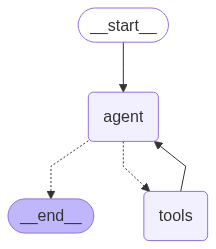

In [34]:
from dotenv import load_dotenv

load_dotenv()

# Import relevant functionality
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

# Create the agent
memory = MemorySaver()
model = init_chat_model("gpt-4o-mini", model_provider="openai")
search = TavilySearch(max_results=2)
tools = [search]
agent_executor = create_react_agent(model,tools, checkpointer=memory)
agent_executor

In [36]:
# Use the agent
config = {"configurable": {"thread_id": "abc123"}}

input_message = {
    "role": "user",
    "content": "Hi, I'm Bob and I live in SF.",
}
for step in agent_executor.stream(
    {"messages": [input_message]}, config, stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, I'm Bob and I live in SF.
================================== Ai Message ==================================

Hi Bob! It's great to meet you. How can I assist you today?


In [37]:

input_message = {
    "role": "user",
    "content": "What's the weather where I live?",
}

for step in agent_executor.stream(
    {"messages": [input_message]}, config, stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What's the weather where I live?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_X3DuNnhnHsr0epq5DHuiyw3q)
 Call ID: call_X3DuNnhnHsr0epq5DHuiyw3q
  Args:
    query: San Francisco weather
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "San Francisco weather", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in San Francisco, California", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1756812111, 'localtime': '2025-09-02 04:21'}, 'current': {'last_updated_epoch': 1756811700, 'last_updated': '2025-09-02 04:15', 'temp_c': 17.2, 'temp_

#### Define tools

In [40]:
from langchain_tavily import TavilySearch

search = TavilySearch(max_results=2)
search_results = search.invoke("What is the weather in SF")
print(search_results)
# If we want, we can create other tools.
# Once we have all the tools we want, we can put them in a list that we will reference later.
tools = [search]
tools

{'query': 'What is the weather in SF', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'title': 'Weather in San Francisco, CA', 'url': 'https://www.weatherapi.com/', 'content': "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1756811840, 'localtime': '2025-09-02 04:17'}, 'current': {'last_updated_epoch': 1756811700, 'last_updated': '2025-09-02 04:15', 'temp_c': 17.2, 'temp_f': 63.0, 'is_day': 0, 'condition': {'text': 'Partly cloudy', 'icon': '//cdn.weatherapi.com/weather/64x64/night/116.png', 'code': 1003}, 'wind_mph': 5.1, 'wind_kph': 8.3, 'wind_degree': 233, 'wind_dir': 'SW', 'pressure_mb': 1012.0, 'pressure_in': 29.88, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 84, 'cloud': 50, 'feelslike_c': 17.2, 'feelslike_f': 63.0, 'windchill_c': 13.6, 'windchill_f': 56.5, 'heatindex_c': 14.1, 'heatindex_f': 57.4, 'dewpoint_c': 13.

[TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))]

In [39]:

model = init_chat_model("gemini-2.5-flash", model_provider="google_genai")

In [41]:
query = "Hi!"
response = model.invoke([{"role": "user", "content": query}])
response.text()

'Hi there! How can I help you today?'

In [42]:
model_with_tools = model.bind_tools(tools)
model_with_tools

RunnableBinding(bound=ChatGoogleGenerativeAI(model='models/gemini-2.5-flash', google_api_key=SecretStr('**********'), client=<google.ai.generativelanguage_v1beta.services.generative_service.client.GenerativeServiceClient object at 0x7f00089eb9d0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of dom

In [43]:
query = "Hi!"
response = model_with_tools.invoke([{"role": "user", "content": query}])

print(f"Message content: {response.text()}\n")
print(f"Tool calls: {response.tool_calls}")

Message content: Hello! How can I help you today?

Tool calls: []


In [44]:
query = "Search for the weather in SF"
response = model_with_tools.invoke([{"role": "user", "content": query}])

print(f"Message content: {response.text()}\n")
print(f"Tool calls: {response.tool_calls}")

Message content: 

Tool calls: [{'name': 'tavily_search', 'args': {'query': 'weather in SF'}, 'id': '1e6f767d-5111-44a4-b1ae-8014b77b0863', 'type': 'tool_call'}]


#### Create the agent

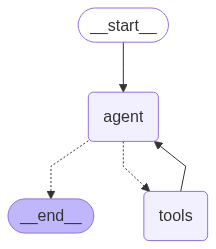

In [45]:
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(model, tools)
agent_executor

#### Run the agent

In [46]:
input_message = {"role": "user", "content": "Hi!"}
response = agent_executor.invoke({"messages": [input_message]})

for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi!
================================== Ai Message ==================================

Hello! How can I help you today?


In [51]:
input_message = {"role": "user", "content": "Search for the weather in SF"}
response = agent_executor.invoke({"messages": [input_message]})

for idx, message in enumerate(response["messages"]):
    print(idx)
    message.pretty_print()

0
================================ Human Message =================================

Search for the weather in SF
1
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8f1d9d3f-0cb8-425f-a287-03bf35cb68a1)
 Call ID: 8f1d9d3f-0cb8-425f-a287-03bf35cb68a1
  Args:
    query: weather in SF
2
================================= Tool Message =================================
Name: tavily_search

{"query": "weather in SF", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in San Francisco", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1756812890, 'localtime': '2025-09-02 04:34'}, 'current': {'last_updated_epoch': 1756812600, 'last_updated': '2025-09-02 04:30', 'temp_c': 17.2, 'temp_f': 63.0, 'is_day': 0, 'conditi

##### Streaming Messages

In [52]:
for idx, step in enumerate(agent_executor.stream({"messages": [input_message]}, stream_mode="values")):
    print(idx)
    step["messages"][-1].pretty_print()

0
================================ Human Message =================================

Search for the weather in SF
1
================================== Ai Message ==================================
Tool Calls:
  tavily_search (aef3b7cc-9b8b-46ba-8261-fdf4b6936a36)
 Call ID: aef3b7cc-9b8b-46ba-8261-fdf4b6936a36
  Args:
    query: weather in SF
2
================================= Tool Message =================================
Name: tavily_search

{"query": "weather in SF", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in San Francisco", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1756812890, 'localtime': '2025-09-02 04:34'}, 'current': {'last_updated_epoch': 1756812600, 'last_updated': '2025-09-02 04:30', 'temp_c': 17.2, 'temp_f': 63.0, 'is_day': 0, 'conditi

##### Streaming tokens

In [4]:
from langgraph.prebuilt import create_react_agent
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch

search = TavilySearch(max_results=2)

model = init_chat_model("gemini-2.5-flash", model_provider="google_genai")
tools = [search]

agent_executor = create_react_agent(model,
                                    tools)

input_message = {"role": "user", "content": "Search for the weather in SF"}

for step, metadata in agent_executor.stream({"messages": [input_message]},
                                            stream_mode="messages"):
    
    if metadata["langgraph_node"] == "agent" and (text := step.text()):
        print(text, end="|")

The current weather in San Francisco is partly cloudy with a temperature of 62.1°F, feeling like 62.1°F. The wind is blowing at 5.1 mph, and the humidity is 84%.|

#### Adding in memory

In [22]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
model = ChatOpenAI(model="gpt-4o-mini", streaming=True)
tools = [] 

In [23]:
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(model, tools, checkpointer=memory)

config = {"configurable": {"thread_id": "abc123"}}

In [24]:
input_message = {"role": "user", "content": "Hi, I'm Bob!"}

for step in agent_executor.stream(
    {"messages": [input_message]},
    config,
    stream_mode="values"):

    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, I'm Bob!
================================== Ai Message ==================================

Hi Bob! How can I assist you today?


In [25]:
input_message = {"role": "user", "content": "What's my name?"}
for step in agent_executor.stream(
    {"messages": [input_message]}, config, stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What's my name?
================================== Ai Message ==================================

Your name is Bob. How can I help you today, Bob?


In [26]:
config = {"configurable": {"thread_id": "xyz123"}}

input_message = {"role": "user", "content": "What's my name?"}
for step in agent_executor.stream(
    {"messages": [input_message]}, config, stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What's my name?
================================== Ai Message ==================================

I’m sorry, but I don’t have access to personal information about you unless you share it with me during our conversation. What would you like me to call you?
